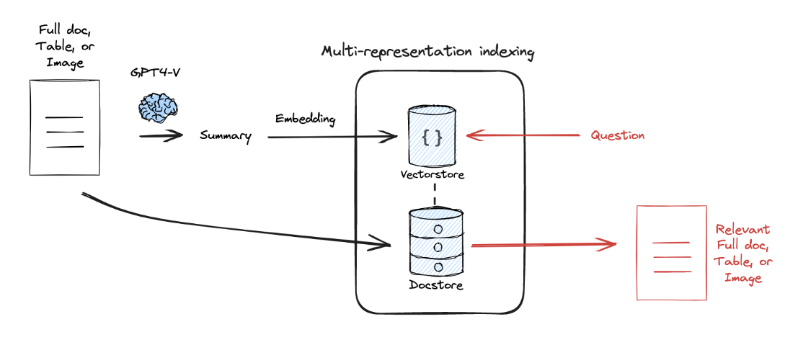

In [ ]:
import os
import uuid
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.vectorstores import Chroma
from langchain_core.stores import InMemoryByteStore
from langchain_classic.retrievers import MultiVectorRetriever
from langchain_core.runnables import RunnableLambda, RunnablePassthrough, RunnableParallel
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

# ==========================================
# 1. INITIALIZE GEMINI MODELS & EMBEDDINGS
# ==========================================
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0)

# Google's native text embedding model
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")


In [22]:
# ==========================================
# 2. DATA LOADING & PARENT CHUNKING
# ==========================================
print("Loading source documents...")
loader = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/")
raw_docs = loader.load()

# Handling massive files: Break raw docs into logical "Parent Chunks" (e.g., ~4 pages each)
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=6000, chunk_overlap=500)
parent_docs = parent_splitter.split_documents(raw_docs)
print(f"Created {len(parent_docs)} Parent Chunks from the raw documents.")
parent_docs

Loading source documents...
Created 9 Parent Chunks from the raw documents.


[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [23]:
# ==========================================
# 3. SUMMARIZATION VIA LCEL
# ==========================================
# Define an LCEL chain designed to summarize each Parent Chunk cleanly
summary_prompt = ChatPromptTemplate.from_template(
    "You are an expert technical assistant. Summarize the following document chunk "
    "comprehensively. Ensure key technical concepts, tool usage, and structural ideas "
    "are preserved for future search retrieval.\n\nDocument Chunk:\n{doc_content}"
)

# LCEL Pipeline: Content Extraction -> Prompt -> Gemini -> Parse to String


summary_chain = (
    RunnableLambda(lambda doc: {"doc_content": doc.page_content})
    | summary_prompt
    | llm
    | StrOutputParser()
)

print("Generating summaries for parent chunks in parallel batches...")
# Using batch execution for high concurrency speeds
summaries = summary_chain.batch(parent_docs, {"max_concurrency": 1})
summaries

Generating summaries for parent chunks in parallel batches...


['### Executive Summary: LLM-Powered Autonomous Agents\nThis document outlines the architectural framework for autonomous agents that utilize Large Language Models (LLMs) as a central "brain." These systems move beyond simple text generation to function as general-purpose problem solvers by integrating planning, memory, and tool-use capabilities.\n\n---\n\n#### 1. Core Architectural Components\n*   **Planning:** Enables the agent to break down complex objectives into manageable subgoals and refine its strategy through self-reflection.\n*   **Memory:** \n    *   *Short-term:* Utilizes in-context learning (prompting) to maintain immediate task state.\n    *   *Long-term:* Employs external vector stores and retrieval mechanisms (e.g., Maximum Inner Product Search - MIPS) to retain and recall information over extended periods.\n*   **Tool Use:** Allows the agent to interface with external APIs, code execution environments, and proprietary data sources to overcome the limitations of static 

In [ ]:
# ==========================================
# 4. INITIALIZE STORE LAYERS & RETRIEVER
# ==========================================
# Vector Store holds the embedded small/summary documents
vectorstore = Chroma(collection_name="gemini_summaries", embedding_function=embeddings)

# Document Store holds the large, full Parent Chunks
byte_store = InMemoryByteStore()
id_key = "doc_id"

# Orchestrator to tie the multi-vector search together
retriever = MultiVectorRetriever(
    vectorstore=vectorstore,
    byte_store=byte_store,
    id_key=id_key,  #connector key to link vectorstore entries to byte_store entries
)
retriever

MultiVectorRetriever(vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x0000021428563190>, byte_store=<langchain_core.stores.InMemoryByteStore object at 0x00000214284EBFD0>, docstore=<langchain_classic.storage.encoder_backed.EncoderBackedStore object at 0x000002142967A810>, search_kwargs={})

In [31]:

# ==========================================
# 5. LINKING DATA AND SEEDING STORES
# ==========================================
# Generate distinct mapping UUIDs matching the number of Parent Chunks
doc_ids = [str(uuid.uuid4()) for _ in parent_docs]

# Convert standard text summaries into LangChain Document objects injected with the metadata pointer
summary_docs = [
    Document(page_content=summary, metadata={id_key: doc_ids[i]})
    for i, summary in enumerate(summaries)
]

print("Seeding Vector Store (Summaries) and Doc Store (Parent Chunks)...")
retriever.vectorstore.add_documents(summary_docs)   # Index summaries for semantic search
retriever.docstore.mset(list(zip(doc_ids, parent_docs))) # Map UUID to full Parent Text

Seeding Vector Store (Summaries) and Doc Store (Parent Chunks)...


In [32]:
# ==========================================
# 6. DESIGNING FINAL RAG PIPELINE (LCEL)
# ==========================================
def format_docs(docs):
    """Helper function to aggregate text content from returned parent documents."""
    return "\n\n---NEXT CHUNK---\n\n".join(doc.page_content for doc in docs)

# The RAG Prompt
rag_prompt_template = """Answer the user question based ONLY on the provided context. 
If the context does not contain enough information to answer, state clearly that you don't know.

Context:
{context}

Question: {question}

Answer:"""
rag_prompt = ChatPromptTemplate.from_template(rag_prompt_template)

# Complete End-to-End LCEL RAG Chain
# Flow: User inputs string -> Vector search summary -> Doc store pulls full Parent text -> Formats -> LLM Answer
rag_chain = (
    {
        "context": retriever | format_docs,  # Pipes retrieval directly into string formatting
        "question": RunnablePassthrough()    # Passes user query string straight through
    }
    | rag_prompt
    | llm
    | StrOutputParser()
)

In [33]:
# ==========================================
# 7. EXECUTION / VERIFICATION
# ==========================================
query = "What are the different types of memory architectures implemented in agents?"
print(f"\n--- Running query: '{query}' ---")

# Execute LCEL chain
response = rag_chain.invoke(query)

print("\n[Gemini Answer Based On Retrieved Parent Context]:\n")
print(response)


--- Running query: 'What are the different types of memory architectures implemented in agents?' ---


c:\Users\asoha\Desktop\cse\langchain_learning\.venv\Lib\site-packages\langchain_classic\storage\_lc_store.py:28: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  obj = loads(serialized.decode("utf-8"))



[Gemini Answer Based On Retrieved Parent Context]:

Based on the provided text, the memory architectures implemented in agents are categorized as follows:

*   **Short-term memory:** This corresponds to in-context learning. It is finite and restricted by the context window length of the Transformer.
*   **Long-term memory:** This provides the agent with the capability to retain and recall information over extended periods. It is often implemented as an external vector store that the agent can attend to at query time, accessible via fast retrieval (such as Maximum Inner Product Search).
*   **Dynamic memory:** Mentioned in the context of the Reflexion framework, which equips agents with dynamic memory and self-reflection capabilities.
*   **Memory stream:** Used in the Generative Agents simulation, this is a long-term memory module (external database) that records a comprehensive list of an agent's experiences in natural language.
